In [141]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5.4-mini"
)

In [142]:
from typing import TypedDict

class GraphState(TypedDict):
    resume_code: str
    job_description: str
    resume_keywords: list[str]
    jd_keywords: list[str]
    similar_keywords: list[str]


### 2. Define the output schema



In [143]:
from pydantic import BaseModel

class KeywordOutput(BaseModel):
    keywords: list[str]

class SimilarKeywordsOutput(BaseModel):
    similar_keywords: list[str]

### 3. Create a structured LLM


In [144]:
structured_llm = llm.with_structured_output(KeywordOutput)
structured_similarity_llm = llm.with_structured_output(SimilarKeywordsOutput)

### 4. Write the extraction node


In [145]:
def extract_latex_keywords(state: GraphState):
    """
    Extracts ATS-relevant keywords from the provided LaTeX resume code.

    Args:
        state (GraphState): The current graph state containing the resume code.

    Returns:
        dict: A dictionary containing the extracted keywords that will be
        merged into the LangGraph state.
    """

    prompt = f"""
    You are an ATS resume keyword extraction expert.

    Extract ONLY ATS-relevant keywords from the following LaTeX resume.

    Include:
    - Programming languages
    - Frameworks
    - Libraries
    - Tools
    - Databases
    - Cloud platforms
    - DevOps technologies
    - APIs
    - AI/ML technologies
    - Software engineering concepts
    - Methodologies
    - Protocols
    - Explicitly mentioned soft skills

    Rules:
    - Ignore all LaTeX commands.
    - Ignore company names unless they are technologies.
    - Remove duplicates.
    - Preserve the original casing.
    - Do not infer technologies that are not explicitly mentioned.

    Resume:
    {state["resume_code"]}
    """

    result = structured_llm.invoke(prompt)

    return {
        "resume_keywords": result.keywords
    }


def extract_jd_keywords(state: GraphState):
    """
    Extracts ATS-relevant keywords from the provided Job Description of a Company.

    Args:
        state (GraphState): The current graph state containing the Job Description.

    Returns:
        dict: A dictionary containing the extracted keywords that will be
        merged into the LangGraph state.

    Rules:
        - Remove duplicates.
        - Ignore company names.
        - Ignore generic English words.
        - Preserve original wording.
    """

    prompt = f"""
    You are an ATS keyword extractor.

    Given the following Job Description, Extract only 
    explicitly mentioned technical skills,
    frameworks, tools, programming languages,
    APIs, concepts, databases, cloud technologies,
    and soft skills if they are explicitly stated.

    Return only the extracted keywords.

    Job Description:
    {state["job_description"]}
    """

    result = structured_llm.invoke(prompt)

    return {
        "jd_keywords": result.keywords
    }


def find_similar_keywords(state: GraphState):
    """
    Compares each keyword from both the GraphState and Gives all the similar keywords that match, with meaning, intend, wording

    Example1: Docker and Dockerization macthes with wording
    Example2: Docker and Devops matches with intend

    Args:
        state (GraphState): The current graph state containing the Resume Keywords and JD Keywords.

    Returns:
        dict: A dictionary of macthed keywords that will be
        merged into the LangGraph state.
    """

    prompt = f"""
    You are an ATS resume comparison expert.

    Compare the following keyword lists.

    Resume Keywords:
    {state["resume_keywords"]}

    Job Description Keywords:
    {state["jd_keywords"]}

    A keyword is considered a match if it is:

    - exactly identical
    - a common abbreviation
    - a synonym
    - the same technology with different wording
    - a parent/child technology
    - a closely related ATS concept

    Examples

    REST API == REST APIs
    Node == Node.js
    React == React.js
    Docker == Dockerization
    CI/CD == Continuous Integration & Continuous Deployment
    RBAC == Role-Based Access Control
    JWT == JWT Authentication

    Rules

    - Return ONLY matched keywords.
    - Do NOT return keywords unique to either list.
    - Remove duplicates.
    - Prefer the standardized keyword.
    """

    result = structured_similarity_llm.invoke(prompt)

    return {
        "similar_keywords": result.similar_keywords
    }

In [146]:
from langgraph.graph import StateGraph, START, END


graph = StateGraph(GraphState)


graph.add_node('extract_latex_keywords', extract_latex_keywords)
graph.add_node('extract_jd_keywords', extract_jd_keywords)
graph.add_node('find_similar_keywords', find_similar_keywords)

graph.add_edge(START, 'extract_latex_keywords')
graph.add_edge(START, 'extract_jd_keywords')

graph.add_edge('extract_latex_keywords', 'find_similar_keywords')
graph.add_edge('extract_jd_keywords', 'find_similar_keywords')
graph.add_edge('find_similar_keywords', END)


workflow = graph.compile()



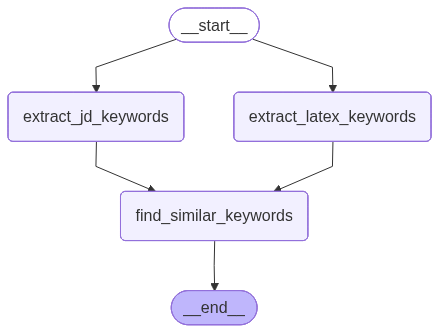

In [147]:
workflow

In [148]:
resume_code = r"""
%-------------------------
% Resume in Latex
% Author : Audric Serador
% Inspired by: https://github.com/sb2nov/resume
% License : MIT
%------------------------

\documentclass[a4paper,11pt]{article}

\usepackage{fontawesome5}
\usepackage{latexsym}
\usepackage[empty]{fullpage}
\usepackage{titlesec}
\usepackage{marvosym}
\usepackage[usenames,dvipsnames]{color}
\usepackage{verbatim}
\usepackage{enumitem}
\usepackage[hidelinks]{hyperref}
\usepackage{fancyhdr}
\usepackage[english]{babel}
\usepackage{tabularx}
\input{glyphtounicode}

\usepackage[default]{lato}

\pagestyle{fancy}
\fancyhf{}
\fancyfoot{}
\renewcommand{\headrulewidth}{0pt}
\renewcommand{\footrulewidth}{0pt}

\addtolength{\oddsidemargin}{-0.5in}
\addtolength{\evensidemargin}{-0.5in}
\addtolength{\textwidth}{1in}
\addtolength{\topmargin}{-.5in}
\addtolength{\textheight}{1.0in}

\urlstyle{same}
\raggedbottom
\raggedright
\setlength{\tabcolsep}{0in}

\titleformat{\section}{
  \vspace{-4pt}\scshape\raggedright\large
}{}{0em}{}[\color{black}\titlerule\vspace{-5pt}]

\pdfgentounicode=1

\newcommand{\resumeItem}[1]{
  \item\small{{#1 \vspace{-2pt}}}
}

\newcommand{\resumeSubheading}[4]{
  \vspace{-2pt}\item
    \begin{tabular*}{0.97\textwidth}[t]{l@{\extracolsep{\fill}}r}
      \textbf{#1} & #2 \\
      \textit{\small#3} & \textit{\small #4} \\
    \end{tabular*}\vspace{-7pt}
}

\newcommand{\resumeProjectHeading}[2]{
    \item
    \begin{tabular*}{0.97\textwidth}{l@{\extracolsep{\fill}}r}
      \small#1 & #2 \\
    \end{tabular*}\vspace{-7pt}
}

\newcommand{\resumeSubHeadingListStart}{\begin{itemize}[leftmargin=0.15in, label={}]}
\newcommand{\resumeSubHeadingListEnd}{\end{itemize}}
\newcommand{\resumeItemListStart}{\begin{itemize}}
\newcommand{\resumeItemListEnd}{\end{itemize}\vspace{-5pt}}

\begin{document}

%----------HEADING----------%

\begin{center}
    {\Huge \scshape Tousif Tamboli} \\ \vspace{5pt}
    \small
    7666839558 $|$
    \href{mailto:tousiftamboli3@gmail.com}{\underline{tousiftamboli3@gmail.com}} $|$
    \href{https://github.com/TousifTamboli}{\underline{github.com/TousifTamboli}} \\[2pt]
    \small
    \href{https://leetcode.com/u/TousifTamboli/}{\underline{leetcode.com/TousifTamboli}} $|$
    \href{https://www.linkedin.com/in/tousif-tamboli-545357221}{\underline{linkedin.com/in/tousif-tamboli-545357221}} $|$
    \href{https://www.tousif.online/}{\underline{my-portfolio.com}}
    
\end{center}

%-----------EXPERIENCE-----------%

\section{Experience}
  \resumeSubHeadingListStart

    \resumeSubheading
      {Software Developer Intern}{\small Dec 2025 -- Jun 2026}
      {Tortus AI}{Remote}

     \resumeItemListStart
        \resumeItem{Engineered and maintained scalable backend services using NodeJs, MongoDB, integrated an AI-powered chatbot into the production website using LLM APIs; collaborated cross-functionally in an Agile/Scrum environment, contributing to sprint deliverables for a platform serving 500k+ users with 99.9\% uptime.}
        
        \resumeItem{Architected and automated CI/CD pipelines using Docker, Docker Compose, and GitHub Actions, streamlining multi-environment deployments; managed DevOps infrastructure, reducing deployment overhead by 35\% and accelerating release cycles across the engineering team.}
    \resumeItemListEnd

  \resumeSubHeadingListEnd

%-----------PROJECTS-----------%

\section{Projects}
    \resumeSubHeadingListStart

      \resumeProjectHeading
          {\textbf{\href{https://github.com/TousifTamboli/youtube-summarize-rag-langchain}{\underline{YouTube Video Analyzer — AI/LLM-Powered RAG Application}}}}{\small Jun 2026}

          \resumeItemListStart
            \resumeItem{Built a full-stack RAG application with a React.js frontend and Python/FastAPI backend, enabling real-time NLP-based video content processing via LangChain, HuggingFace Embeddings, OpenAI LLMs, and the YouTube Transcript API; containerized with Docker for team collaboration.}
            \resumeItem{Eliminated manual video review by allowing users to generate AI summaries and hold conversational Q\&A sessions with any YouTube video, reducing content review time by an estimated 60\%.}
        \resumeItemListEnd

        \resumeProjectHeading
          {\textbf{\href{https://github.com/TousifTamboli/web-based-rag-using-langchain}{\underline{RAG Chatbot for Stripe Privacy \& Policy Intelligence}}}}{\small Jun 2026}

          \resumeItemListStart
            \resumeItem{Identified that Stripe's compliance information was fragmented across 35+ web pages; built a production-ready RAG chatbot using Python, LangChain, semantic search, OpenAI and Claude LLMs over scraped policy documents; containerized with Docker for cross-team deployment.}
            \resumeItem{Consolidated all policy sources into a single conversational AI-powered interface, reducing average retrieval time by 40\% and improving client satisfaction by 20\%.}
        \resumeItemListEnd

      \resumeProjectHeading
          {\textbf{\href{https://github.com/TousifTamboli/tp-cell-system}{\underline{University Recruitment Automation Suite — MERN Stack}}}}{\small Feb 2026 -- Mar 2026}

          \resumeItemListStart
            \resumeItem{Built a centralized campus recruitment platform using React.js, Node.js, Express.js, MongoDB, and Redis with JWT authentication and RBAC, reducing REST API dashboard response times by 40\% through caching and query optimization.}
            \resumeItem{Automated end-to-end recruitment workflows including application tracking, shortlisting, analytics reporting, audit logging, and CSV exports; followed Agile/Scrum sprint delivery with peer code reviews.}
          \resumeItemListEnd

      \resumeProjectHeading
          {\textbf{\href{https://github.com/TousifTamboli/govguidebot}{\underline{GovGuideBot — AI-Powered NLP Document Assistance System}}}}{\small Jun 2024 -- Jun 2025}

          \resumeItemListStart
            \resumeItem{Designed an RAG pipeline using Python and Web - Crawler with Named Entity Recognition (NER) to extract structured information from government documents, reducing manual lookup effort by 50\%.}
            \resumeItem{Built an intent-processing engine that parses natural-language queries and generates step-by-step procedural guidance; Dockerized for cloud-native open-source.}
          \resumeItemListEnd

    \resumeSubHeadingListEnd

%-----------SKILLS-----------%

\section{Technical Skills}

 \begin{itemize}[leftmargin=0.15in, label={}]
    \small{\item{

     \textbf{Languages}{: C++, Python, JavaScript, SQL} \\

     \textbf{AI / ML}{: LLMs, RAG, LangChain, LangGraph, HuggingFace, Prompt Engineering} \\

     \textbf{Frontend}{: React.js, Next.js, Tailwind CSS} \\

     \textbf{Backend}{: Node.js, Express.js, FastAPI, REST APIs, Redis, Microservices} \\

     \textbf{Databases}{: MongoDB, MySQL} \\

     \textbf{DevOps \& Cloud}{: Docker, GitHub Actions, AWS, CI/CD, Linux} \\

     \textbf{Practices}{: Agile/Scrum, System Design, Code Reviews, GitHub Copilot, Unit Testing}

    }}
 \end{itemize}

 %-----------EDUCATION-----------%

\section{Education}
  \resumeSubHeadingListStart
    \resumeSubheading
      {Savitribai Phule Pune University}{\small 2022 -- 2026}
      {Bachelor of Technology in Computer Science (Data Science)}{CGPA: 8.9}
  \resumeSubHeadingListEnd

%-----------ACHIEVEMENTS-----------%

\section{Achievements}

\resumeItemListStart
\resumeItem{\textbf{LeetCode and Hackathon:} Solved 800+ problems with a Contest Rating of 1650+, TOP 5\% in E-CELL IIT Bombay Hackathon}
\resumeItem{Delivered 5+ freelance full-stack web development projects end-to-end independently, meeting strict client requirements and deadlines across React.js, Node.js, and cloud deployment.}
\resumeItemListEnd

\end{document}
"""

In [149]:
job_description = r"""
About the job
The Back End Software Engineer is responsible for developing the back end of a web application, handling the logic, database interactions, user authentication, configuration, etc. The Back End Software Engineer evaluates emerging technologies and provides strategic, innovative and cost-effective engineering solutions to increase the efficiency, reliability and integration of Schlumberger services and operations. This person works semi-autonomously as part of a team that performs rapid prototyping of emerging technologies to solve industry-related problems.

Develop server-side logic, definition and maintenance of the central database, and ensure high performance and responsiveness to requests from the front-end developers.
Integrate user-facing elements developed by front-end developers with server-side applications.
Collaborate with front-end developers, customers, users and Product Managers to establish objectives and design functional, cohesive codes to enhance the user experience.
Keep abreast of novel technical concepts and markets.
Provide technical leadership and documentation to developers and stakeholders.
Apply usability procedures and principles as defined at the project or Product Line level or through customer input.
Build prototypes, products and systems that meet the project quality standards and requirements.
Contribute to and support re-use through common components that are well documented and tested.

EPH

SLB is an equal employment opportunity employer. Qualified applicants are considered without regard to race, color, religion, sex, national origin, age, disability, or other characteristics protected by law."""

In [150]:
initial_state = {
    'resume_code': resume_code,
    'job_description': job_description
}

result = workflow.invoke(initial_state)

print(result['similar_keywords'])

['Node.js', 'MongoDB', 'Docker', 'GitHub Actions', 'DevOps', 'React.js', 'Python', 'FastAPI', 'LangChain', 'OpenAI', 'Claude', 'semantic search', 'Express.js', 'Redis', 'JWT authentication', 'RBAC', 'REST API', 'CSV exports', 'RAG', 'Prompt Engineering', 'Next.js', 'Tailwind CSS', 'Microservices', 'MySQL', 'AWS', 'CI/CD', 'Linux', 'System Design', 'Unit Testing', 'JavaScript', 'SQL', 'back end', 'web application', 'server-side logic', 'database', 'user authentication', 'configuration', 'integration', 'rapid prototyping', 'front-end developers', 'users', 'Product Managers', 'user experience', 'technical leadership', 'documentation', 'developers', 'stakeholders', 'requirements']
